In [ ]:
%autosave 300

Autosaving every 300 seconds


In [ ]:
#downloading CLIP and torchvision
!pip install torch torchvision ftfy regex tqdm Pillow
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-j94ukfk5
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-j94ukfk5
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=7731cf5635ffe7216998657630e71074ce29ed57e784d87295784673f714ad35
  Stored in directory: /tmp/pip-ephem-wheel-cache-q9drfkgm/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
#mounting drive
from google.colab import drive
import torch
drive.mount('/content/drive/',force_remount=True)

faRL = "/content/drive/My Drive/ColourAnalysis/FaRL-Base-Patch16-LAIONFace20M-ep64.pth"
faRL64 = torch.load(faRL)

Mounted at /content/drive/


In [ ]:
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import os

#BASE DIR
dataset_dir = "/content/drive/My Drive/ColourAnalysis/dataset/greyscale/"
train_dir = os.path.join(dataset_dir,'train')
test_dir = os.path.join(dataset_dir, 'test')
csv_path = "/content/drive/My Drive/ColourAnalysis/dataset/annotations.csv"


#AUGMENTATION
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((256,256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAdjustSharpness(sharpness_factor = 2, p = 0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229])
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229])
    ]),
}

#DATALOADING
try:
  train_dataset = datasets.ImageFolder(train_dir,transform=data_transforms['train'])
  test_dataset = datasets.ImageFolder(test_dir,transform=data_transforms['test'])

  batch_size = 64
  train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
  test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

  class_names = train_dataset.classes
  print(f"Classes found: {class_names}")
  print(f"Training data size: {len(train_dataset)} images")
  print(f"Test data size: {len(test_dataset)} images")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print(f"Please check if the directory exists: {dataset_dir}")

Classes found: ['autunno_deep', 'autunno_soft', 'autunno_warm', 'estate_cool', 'estate_light', 'estate_soft', 'inverno_bright', 'inverno_cool', 'inverno_deep', 'primavera_bright', 'primavera_light', 'primavera_warm']
Training data size: 4008 images
Test data size: 912 images


In [ ]:
#DEFINING MODEL
import torch
import torch.nn as nn
import clip

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:{device}")

#LOAD BASE CLIP MODEL
clip_model_raw,preprocess = clip.load('ViT-B/16',device="cpu")
clip_model_raw = clip_model_raw.to(device)

#LOAD FARL
farl_state = torch.load(faRL)
clip_model_raw.load_state_dict(farl_state["state_dict"],strict=False)

class FaRLImageClassifier(nn.Module):

  def __init__(self, clip_base_model,num_classes=4):
    super(FaRLImageClassifier,self).__init__()
    self.clip_base_model = clip_base_model

    #CHANGE FIRST LAYER
    self.clip_base_model.visual.conv1 = nn.Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)

    for param in self.clip_base_model.parameters():
      param.requires_grad = False

    #UNFREEZE WEIGHTS FOR FIRST LAYER (so model can train w new input??)
    for params in self.clip_base_model.visual.conv1.parameters():
      params.require_grad = True

    classifier = clip_base_model.text_projection.shape[1]
    self.classification_head = nn.Linear(classifier,num_classes)

  def forward(self,x):
    image_features = self.clip_base_model.encode_image(x.type(self.clip_base_model.dtype))
    logits = self.classification_head(image_features)
    return logits

model = FaRLImageClassifier(clip_model_raw,num_classes=len(class_names)).to(device)

print(model)

Device:cuda


100%|████████████████████████████████████████| 335M/335M [00:03<00:00, 110MiB/s]


FaRLImageClassifier(
  (clip_base_model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): Sequential(
          (0): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): QuickGELU()
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          )
          (1): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDyn

In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

In [ ]:
import time
import copy
from tqdm.notebook import tqdm

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dictionaries to store metrics
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = test_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase", leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
model,history = train_model(model,criterion,optimizer,scheduler,num_epochs=25)

Epoch 0/24
----------


train Phase:   0%|          | 0/63 [00:00<?, ?it/s]

train Loss: 2.4499 Acc: 0.1265


test Phase:   0%|          | 0/15 [00:00<?, ?it/s]

test Loss: 2.4167 Acc: 0.1436

Epoch 1/24
----------


...

test Loss: 2.2728 Acc: 0.1787

Epoch 24/24
----------


train Phase:   0%|          | 0/63 [00:00<?, ?it/s]

train Loss: 2.2715 Acc: 0.1921


test Phase:   0%|          | 0/15 [00:00<?, ?it/s]

test Loss: 2.2678 Acc: 0.1798

Training complete in 100m 30s
Best val Acc: 0.1963


In [ ]:
#Store results in json
import json
with open('/content/drive/MyDrive/ColourAnalysis/Evaluation/greyscale12_history.json', 'w') as f:
    json.dump(history, f)

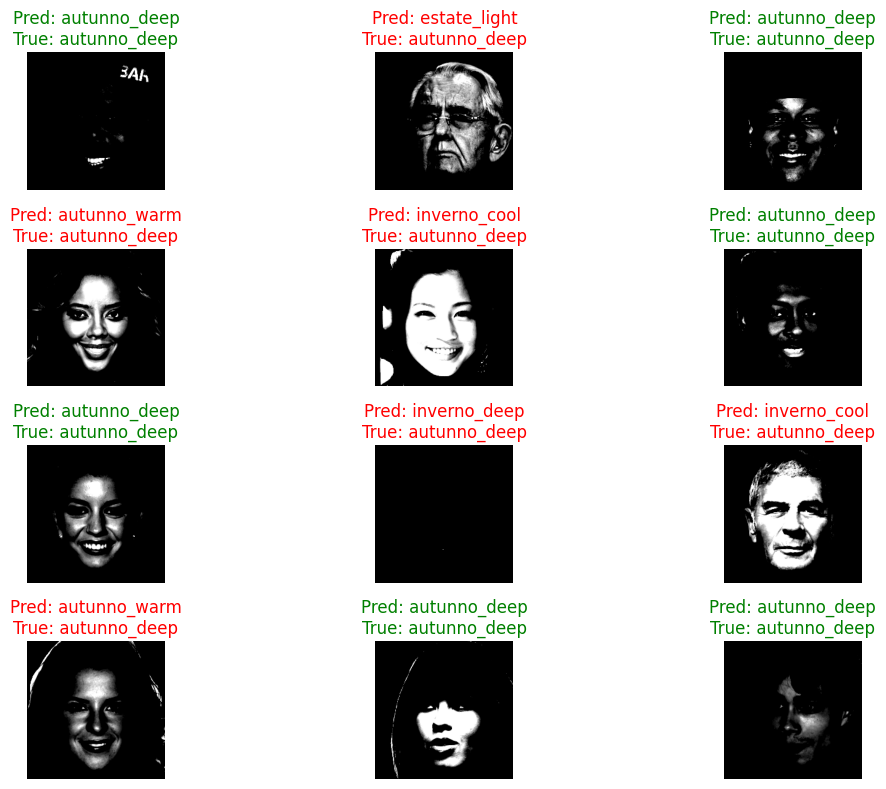

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move to device for prediction
images_cuda = images.to(device)

# Predict
model.eval()
with torch.no_grad():
    outputs = model(images_cuda)
    _, preds = torch.max(outputs, 1)

# Plot the first 6 images
num_images = 12
fig, axes = plt.subplots(4, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(num_images):
    ax = axes[i]
    # Convert Tensor to numpy array and transpose to (H, W, C)
    img = images[i].numpy().transpose((1, 2, 0))
    # Ensure values are valid for plotting (0-1)
    img = np.clip(img, 0, 1)

    ax.imshow(img, cmap='gray')

    pred_label = class_names[preds[i]]
    true_label = class_names[labels[i]]

    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

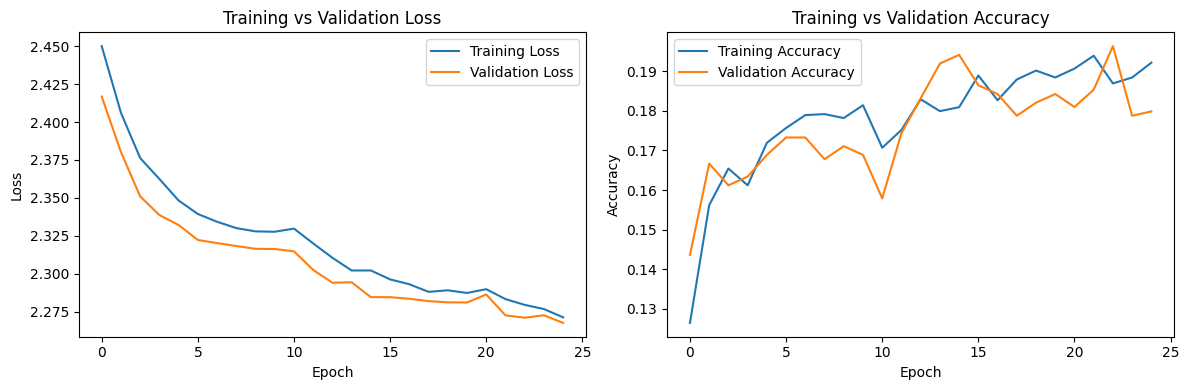

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['test_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['test_acc'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

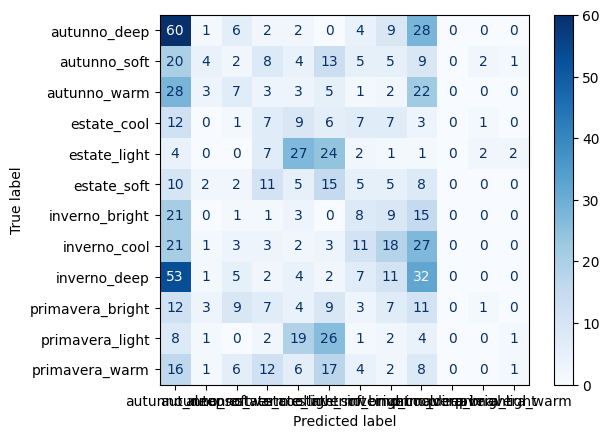

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

model.eval()
class_true = []
class_pred = []

with torch.no_grad():
  for images,labels in test_loader:
    images = images.to(device)
    output = model(images)
    _,predicted = torch.max(output,1)

    class_pred.extend(predicted.cpu().numpy())
    class_true.extend(labels.cpu().numpy())

cm = confusion_matrix(class_true,class_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues')
plt.show()